# Random Forest Road Deterioration Baseline (v2)

This notebook trains `RandomForestRegressor` models for next-measurement prediction.

Changes from v1:
- Added `current_lag_static` feature set: lag features + static road attributes, without lifecycle features.
  This isolates whether static features help independently of lifecycle context.
- Added cells for 1-, 2-, 3- and 4-year horizon prediction.


In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [24]:
DATA_PATH = Path("data/road_model_dataset_v1.parquet")
RANDOM_STATE = 42
TRAIN_SAMPLE_N = 200_000
TEST_SAMPLE_N = 80_000
TRAIN_DATE_QUANTILE = 0.80

In [25]:
use_cols = [
    "event_date",
    "target_next_URA",
    "target_next_IRI",
    "target_horizon_days",
    "baseline_persist_URA",
    "baseline_persist_IRI",
    "URA",
    "IRI",
    "prev_URA",
    "prev_IRI",
    "Delta_t_years",
    "Pavement_Age_years",
    "Initial_URA",
    "Measurement_Idx",
    "Minor_TP_Count",
    "tp_count_interval",
    "has_TP_interval",
    "KVL",
    "KVL_raskas",
    "KVL_kaista",
    "Nopeus",
    "Toim_lk",
]

df = pd.read_parquet(DATA_PATH, columns=use_cols)
df["event_date"] = pd.to_datetime(df["event_date"])
print(df.shape)
display(df.head())

(3833323, 22)


,event_date,target_next_URA,target_next_IRI,target_horizon_days,baseline_persist_URA,baseline_persist_IRI,URA,IRI,prev_URA,prev_IRI,Delta_t_years,Pavement_Age_years,Initial_URA,Measurement_Idx,Minor_TP_Count,tp_count_interval,has_TP_interval,KVL,KVL_raskas,KVL_kaista,Nopeus,Toim_lk
0,2018-06-18,2.7,1.93,1527.0,2.7,1.60,2.7,1.60,NaN,NaN,NaN,0.0,2.7,1,1,1,True,182.0,23.0,80.0,80,yhdys
1,2018-06-18,1.7,1.70,1527.0,1.4,1.50,1.4,1.50,NaN,NaN,NaN,0.0,1.4,1,1,1,True,182.0,23.0,80.0,80,yhdys
2,2018-06-18,1.5,1.91,1527.0,1.5,1.75,1.5,1.75,NaN,NaN,NaN,0.0,1.5,1,1,1,True,182.0,23.0,80.0,80,yhdys
3,2018-06-18,3.5,1.66,1527.0,4.7,1.45,4.7,1.45,NaN,NaN,NaN,0.0,4.7,1,1,1,True,182.0,23.0,80.0,80,yhdys
4,2018-06-18,2.0,2.96,1527.0,1.4,2.42,1.4,2.42,NaN,NaN,NaN,0.0,1.4,1,1,1,True,182.0,23.0,80.0,80,yhdys


### Next measurement prediction
Run ONLY this (ignore the next cell) if you want to predict the next measurement.

In [ ]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df = df.loc[df["event_date"] < cutoff_date].copy()
test_df = df.loc[df["event_date"] >= cutoff_date].copy()


def sample_rows(frame: pd.DataFrame, n: int, random_state: int) -> pd.DataFrame:
    if len(frame) <= n:
        return frame.copy()
    return frame.sample(n=n, random_state=random_state).copy()

train_sample = sample_rows(train_df, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample = sample_rows(test_df, TEST_SAMPLE_N, RANDOM_STATE)

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train sample rows: {len(train_sample):,}")
print(f"Test sample rows: {len(test_sample):,}")

### 1-year horizon prediction

In [26]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df = df.loc[df["event_date"] < cutoff_date].copy()
test_df = df.loc[df["event_date"] >= cutoff_date].copy()

# Filter to 1-year horizon
train_df = train_df[train_df["target_horizon_days"].between(274, 457)].copy()
test_df = test_df[test_df["target_horizon_days"].between(274, 457)].copy()

print(f"1-year horizon train rows: {len(train_df):,}")
print(f"1-year horizon test rows: {len(test_df):,}")

def sample_rows(frame: pd.DataFrame, n: int, random_state: int) -> pd.DataFrame:
    if len(frame) <= n:
        return frame.copy()
    return frame.sample(n=n, random_state=random_state).copy()

train_sample = sample_rows(train_df, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample = sample_rows(test_df, TEST_SAMPLE_N, RANDOM_STATE)

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train sample rows: {len(train_sample):,}")
print(f"Test sample rows: {len(test_sample):,}")

1-year horizon train rows: 1,434,070
1-year horizon test rows: 394,688
Cutoff date: 2020-08-18
Train sample rows: 200,000
Test sample rows: 80,000


In [27]:
def regression_metrics(y_true, y_pred, model_name, target_name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return {
        "model": model_name,
        "target": target_name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse,
        "r2": r2_score(y_true, y_pred),
    }


def split_valid_feature_groups(frame: pd.DataFrame, selected_features):
    available = [c for c in selected_features if c in frame.columns]
    non_empty = [c for c in available if frame[c].notna().any()]
    dropped_all_missing = [c for c in available if c not in non_empty]
    numeric_features = [c for c in non_empty if c != "Toim_lk"]
    categorical_features = [c for c in ["Toim_lk"] if c in non_empty]
    return {
        "available": available,
        "non_empty": non_empty,
        "dropped_all_missing": dropped_all_missing,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
    }


def build_preprocessor(feature_groups):
    transformers = []

    if feature_groups["numeric_features"]:
        transformers.append(
            (
                "num",
                SimpleImputer(strategy="median"),
                feature_groups["numeric_features"],
            )
        )

    if feature_groups["categorical_features"]:
        try:
            one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

        transformers.append(
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", one_hot),
                    ]
                ),
                feature_groups["categorical_features"],
            )
        )

    if not transformers:
        raise ValueError("No valid non-empty feature columns were found for preprocessing.")

    return ColumnTransformer(transformers=transformers)


## Persistence Baseline

In [28]:
rf_results = []

rf_results.append(regression_metrics(test_sample["target_next_URA"], test_sample["baseline_persist_URA"], "persistence", "target_next_URA"))
rf_results.append(regression_metrics(test_sample["target_next_IRI"], test_sample["baseline_persist_IRI"], "persistence", "target_next_IRI"))

pd.DataFrame(rf_results)

,model,target,mae,rmse,r2
0,persistence,target_next_URA,1.898035,2.417047,0.694394
1,persistence,target_next_IRI,0.148239,0.305837,0.766479


## Random Forest Feature Sets

In [29]:
feature_sets = {
    "current_only": ["URA", "IRI"],
    "current_plus_lag": ["URA", "IRI", "prev_URA", "prev_IRI", "Delta_t_years"],
    "current_lag_static": [
        "URA", "IRI",
        "prev_URA", "prev_IRI", "Delta_t_years",
        "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    ],
    "current_lag_lifecycle": [
        "URA", "IRI", "prev_URA", "prev_IRI", "Delta_t_years",
        "Pavement_Age_years", "Initial_URA", "Measurement_Idx", "Minor_TP_Count",
        "tp_count_interval", "has_TP_interval",
    ],
    "current_lag_lifecycle_static": [
        "URA", "IRI", "prev_URA", "prev_IRI", "Delta_t_years",
        "Pavement_Age_years", "Initial_URA", "Measurement_Idx", "Minor_TP_Count",
        "tp_count_interval", "has_TP_interval", "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    ],
}

rf_predictions = {}
rf_feature_importances = {}

In [30]:
for feature_set_name, selected_features in feature_sets.items():
    print(f"\n=== Feature set: {feature_set_name} ===")

    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample[target_name].notna()
        test_target = test_sample[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample.columns]
        X_train = train_sample.loc[train_target, active_features].copy()
        y_train = train_sample.loc[train_target, target_name]
        X_test = test_sample.loc[test_target, active_features].copy()
        y_test = test_sample.loc[test_target, target_name]

        feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(feature_groups)

        print(f"Target: {target_name}")
        print(f"Dropped all-missing features: {feature_groups['dropped_all_missing']}")

        pipe = Pipeline(
            steps=[
                ("preprocess", preprocess),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=200,
                        max_depth=None,
                        min_samples_leaf=5,
                        n_jobs=-1,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        metrics = regression_metrics(y_test, y_pred, "random_forest", target_name)
        metrics["feature_set"] = feature_set_name
        metrics["n_features_used"] = len(feature_groups["non_empty"])
        rf_results.append(metrics)
        rf_predictions[(feature_set_name, target_name)] = (y_test, y_pred)

        feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
        importances = pipe.named_steps["model"].feature_importances_
        rf_feature_importances[(feature_set_name, target_name)] = pd.DataFrame(
            {"feature": feature_names, "importance": importances}
        ).sort_values("importance", ascending=False).reset_index(drop=True)

rf_results_df = pd.DataFrame(rf_results).sort_values(["target", "model", "rmse"]).reset_index(drop=True)
rf_results_df


=== Feature set: current_only ===
Target: target_next_URA
Dropped all-missing features: []
Target: target_next_IRI
Dropped all-missing features: []

=== Feature set: current_plus_lag ===
Target: target_next_URA
Dropped all-missing features: []
Target: target_next_IRI
Dropped all-missing features: []

=== Feature set: current_lag_static ===
Target: target_next_URA
Dropped all-missing features: []
Target: target_next_IRI
Dropped all-missing features: []

=== Feature set: current_lag_lifecycle ===
Target: target_next_URA
Dropped all-missing features: []
Target: target_next_IRI
Dropped all-missing features: []

=== Feature set: current_lag_lifecycle_static ===
Target: target_next_URA
Dropped all-missing features: []
Target: target_next_IRI
Dropped all-missing features: []


,model,target,mae,rmse,r2,feature_set,n_features_used
0,persistence,target_next_IRI,0.148239,0.305837,0.766479,NaN,NaN
1,random_forest,target_next_IRI,0.142833,0.280781,0.803174,current_lag_lifecycle_static,16.0
2,random_forest,target_next_IRI,0.143342,0.281613,0.802006,current_lag_static,10.0
3,random_forest,target_next_IRI,0.143989,0.283106,0.799901,current_lag_lifecycle,11.0
4,random_forest,target_next_IRI,0.144807,0.284482,0.797951,current_plus_lag,5.0
5,random_forest,target_next_IRI,0.153260,0.300955,0.773875,current_only,2.0
6,persistence,target_next_URA,1.898035,2.417047,0.694394,NaN,NaN
7,random_forest,target_next_URA,1.031808,1.487540,0.884248,current_lag_lifecycle_static,16.0
8,random_forest,target_next_URA,1.043661,1.495637,0.882984,current_lag_static,10.0
9,random_forest,target_next_URA,1.099804,1.564450,0.871969,current_lag_lifecycle,11.0


In [31]:
rf_summary = rf_results_df.pivot_table(
    index=["model", "feature_set"],
    columns="target",
    values=["mae", "rmse", "r2"],
)
rf_summary

mae                              r2                            rmse                
target                                     target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
model         feature_set                                                                                                                 
random_forest current_lag_lifecycle               0.143989        1.099804        0.799901        0.871969        0.283106        1.564450
              current_lag_lifecycle_static        0.142833        1.031808        0.803174        0.884248        0.280781        1.487540
              current_lag_static                  0.143342        1.043661        0.802006        0.882984        0.281613        1.495637
              current_only                        0.153260        1.216231        0.773875        0.848356        0.300955        1.702616
              current_plus_lag                    0.144807        1.161261        0.797951        0.861505        0.284482        1.627123

## Feature Importances

In [32]:
for target_name in ["target_next_URA", "target_next_IRI"]:
    best_row = rf_results_df.loc[
        (rf_results_df["model"] == "random_forest") & (rf_results_df["target"] == target_name)
    ].sort_values("rmse").iloc[0]
    best_key = (best_row["feature_set"], target_name)
    print(f"\nTop importances for {target_name} using {best_row['feature_set']}:")
    display(rf_feature_importances[best_key].head(20))


Top importances for target_next_URA using current_lag_lifecycle_static:


,feature,importance
0,num__URA,0.910247
1,num__KVL_kaista,0.027554
2,num__prev_URA,0.010371
3,num__KVL_raskas,0.007634
4,num__Pavement_Age_years,0.007335
5,num__Initial_URA,0.007218
6,num__IRI,0.006452
7,num__KVL,0.006146
8,num__Delta_t_years,0.005880
9,num__prev_IRI,0.004700



Top importances for target_next_IRI using current_lag_lifecycle_static:


,feature,importance
0,num__IRI,0.894010
1,num__prev_IRI,0.029806
2,num__KVL_raskas,0.011004
3,num__URA,0.009981
4,num__Delta_t_years,0.009002
5,num__Pavement_Age_years,0.008482
6,num__Initial_URA,0.008109
7,num__KVL,0.007806
8,num__KVL_kaista,0.006829
9,num__prev_URA,0.006335


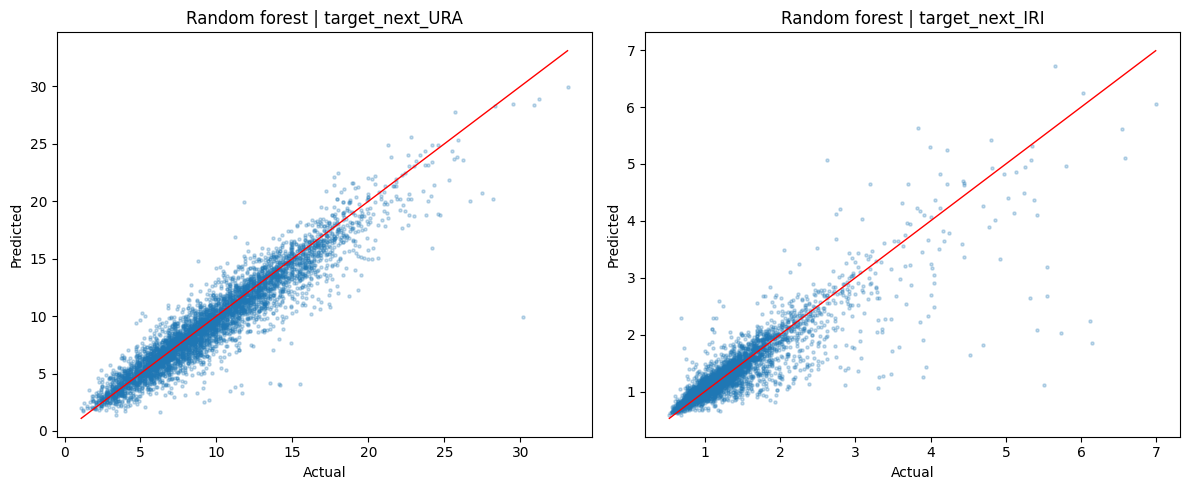

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, target_name in enumerate(["target_next_URA", "target_next_IRI"]):
    best_row = rf_results_df.loc[
        (rf_results_df["model"] == "random_forest") & (rf_results_df["target"] == target_name)
    ].sort_values("rmse").iloc[0]
    y_true, y_pred = rf_predictions[(best_row["feature_set"], target_name)]
    plot_df = pd.DataFrame({"actual": y_true, "predicted": y_pred}).sample(
        n=min(5000, len(y_true)),
        random_state=RANDOM_STATE,
    )

    ax = axes[idx]
    ax.scatter(plot_df["actual"], plot_df["predicted"], s=5, alpha=0.25)
    lo = min(plot_df["actual"].min(), plot_df["predicted"].min())
    hi = max(plot_df["actual"].max(), plot_df["predicted"].max())
    ax.plot([lo, hi], [lo, hi], color="red", linewidth=1)
    ax.set_title(f"Random forest | {target_name}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()

### 2-year horizon prediction

In [34]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df_2yr = df.loc[df["event_date"] < cutoff_date].copy()
test_df_2yr = df.loc[df["event_date"] >= cutoff_date].copy()

train_df_2yr = train_df_2yr[train_df_2yr["target_horizon_days"].between(639, 822)].copy()
test_df_2yr = test_df_2yr[test_df_2yr["target_horizon_days"].between(639, 822)].copy()

print(f"2-year horizon train rows: {len(train_df_2yr):,}")
print(f"2-year horizon test rows:  {len(test_df_2yr):,}")
print(f"Mean horizon days: {train_df_2yr['target_horizon_days'].mean():.1f}")


2-year horizon train rows: 300,241
2-year horizon test rows:  133,130
Mean horizon days: 728.3


In [35]:
train_sample_2yr = sample_rows(train_df_2yr, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample_2yr  = sample_rows(test_df_2yr,  TEST_SAMPLE_N,  RANDOM_STATE)
print(f"Train sample: {len(train_sample_2yr):,}  Test sample: {len(test_sample_2yr):,}")


Train sample: 200,000  Test sample: 80,000


In [36]:
rf_results_2yr = []

# Persistence
rf_results_2yr.append(regression_metrics(test_sample_2yr["target_next_URA"], test_sample_2yr["baseline_persist_URA"], "persistence", "target_next_URA"))
rf_results_2yr.append(regression_metrics(test_sample_2yr["target_next_IRI"], test_sample_2yr["baseline_persist_IRI"], "persistence", "target_next_IRI"))

rf_predictions_2yr = {}
rf_importances_2yr = {}

for feature_set_name, selected_features in feature_sets.items():
    print(f"\n=== {feature_set_name} ===")
    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample_2yr[target_name].notna()
        test_target  = test_sample_2yr[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample_2yr.columns]
        X_train = train_sample_2yr.loc[train_target, active_features].copy()
        y_train = train_sample_2yr.loc[train_target, target_name]
        X_test  = test_sample_2yr.loc[test_target,  active_features].copy()
        y_test  = test_sample_2yr.loc[test_target,  target_name]

        feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(feature_groups)

        from sklearn.ensemble import RandomForestRegressor
        from sklearn.pipeline import Pipeline
        pipe = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)),   # Changed n_estimator to 100 for faster runs, but can be increased for better performance
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        m = regression_metrics(y_test, y_pred, "random_forest", target_name)
        m["feature_set"] = feature_set_name
        rf_results_2yr.append(m)
        rf_predictions_2yr[(feature_set_name, target_name)] = (y_test, y_pred)

        feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
        importances = pipe.named_steps["model"].feature_importances_
        rf_importances_2yr[(feature_set_name, target_name)] = (
            pd.DataFrame({"feature": feature_names, "importance": importances})
            .sort_values("importance", ascending=False).reset_index(drop=True)
        )

rf_df_2yr = pd.DataFrame(rf_results_2yr).sort_values(["target", "model", "rmse"]).reset_index(drop=True)
summary_rf_2yr = rf_df_2yr.pivot_table(index=["model", "feature_set"], columns="target", values=["mae", "rmse", "r2"])

print("\n=== 2-year horizon — results ===")
display(summary_rf_2yr)



=== current_only ===

=== current_plus_lag ===

=== current_lag_static ===

=== current_lag_lifecycle ===

=== current_lag_lifecycle_static ===

=== 2-year horizon — results ===


mae                              r2                            rmse                
target                                     target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
model         feature_set                                                                                                                 
random_forest current_lag_lifecycle               0.226658        1.338914        0.831114        0.832466        0.366012        1.833988
              current_lag_lifecycle_static        0.224703        1.229057        0.834553        0.852247        0.362265        1.722316
              current_lag_static                  0.225544        1.245320        0.832947        0.848319        0.364019        1.745062
              current_only                        0.233111        1.398846        0.816274        0.820297        0.381753        1.899429
              current_plus_lag                    0.226711        1.352534        0.830049        0.828689        0.367164        1.854549

### 3-year horizon prediction

In [37]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df_3yr = df.loc[df["event_date"] < cutoff_date].copy()
test_df_3yr = df.loc[df["event_date"] >= cutoff_date].copy()

train_df_3yr = train_df_3yr[train_df_3yr["target_horizon_days"].between(1004, 1187)].copy()
test_df_3yr = test_df_3yr[test_df_3yr["target_horizon_days"].between(1004, 1187)].copy()

print(f"3-year horizon train rows: {len(train_df_3yr):,}")
print(f"3-year horizon test rows:  {len(test_df_3yr):,}")
print(f"Mean horizon days: {train_df_3yr['target_horizon_days'].mean():.1f}")


3-year horizon train rows: 663,314
3-year horizon test rows:  171,818
Mean horizon days: 1100.1


In [38]:
train_sample_3yr = sample_rows(train_df_3yr, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample_3yr  = sample_rows(test_df_3yr,  TEST_SAMPLE_N,  RANDOM_STATE)
print(f"Train sample: {len(train_sample_3yr):,}  Test sample: {len(test_sample_3yr):,}")


Train sample: 200,000  Test sample: 80,000


In [39]:
rf_results_3yr = []

# Persistence
rf_results_3yr.append(regression_metrics(test_sample_3yr["target_next_URA"], test_sample_3yr["baseline_persist_URA"], "persistence", "target_next_URA"))
rf_results_3yr.append(regression_metrics(test_sample_3yr["target_next_IRI"], test_sample_3yr["baseline_persist_IRI"], "persistence", "target_next_IRI"))

rf_predictions_3yr = {}
rf_importances_3yr = {}

for feature_set_name, selected_features in feature_sets.items():
    print(f"\n=== {feature_set_name} ===")
    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample_3yr[target_name].notna()
        test_target  = test_sample_3yr[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample_3yr.columns]
        X_train = train_sample_3yr.loc[train_target, active_features].copy()
        y_train = train_sample_3yr.loc[train_target, target_name]
        X_test  = test_sample_3yr.loc[test_target,  active_features].copy()
        y_test  = test_sample_3yr.loc[test_target,  target_name]

        feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(feature_groups)

        from sklearn.ensemble import RandomForestRegressor
        from sklearn.pipeline import Pipeline
        pipe = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)),   # Changed n_estimator to 100 for faster runs, but can be increased for better performance
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        m = regression_metrics(y_test, y_pred, "random_forest", target_name)
        m["feature_set"] = feature_set_name
        rf_results_3yr.append(m)
        rf_predictions_3yr[(feature_set_name, target_name)] = (y_test, y_pred)

        feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
        importances = pipe.named_steps["model"].feature_importances_
        rf_importances_3yr[(feature_set_name, target_name)] = (
            pd.DataFrame({"feature": feature_names, "importance": importances})
            .sort_values("importance", ascending=False).reset_index(drop=True)
        )

rf_df_3yr = pd.DataFrame(rf_results_3yr).sort_values(["target", "model", "rmse"]).reset_index(drop=True)
summary_rf_3yr = rf_df_3yr.pivot_table(index=["model", "feature_set"], columns="target", values=["mae", "rmse", "r2"])

print("\n=== 3-year horizon — results ===")
display(summary_rf_3yr)



=== current_only ===

=== current_plus_lag ===

=== current_lag_static ===

=== current_lag_lifecycle ===

=== current_lag_lifecycle_static ===

=== 3-year horizon — results ===


mae                              r2                            rmse                
target                                     target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
model         feature_set                                                                                                                 
random_forest current_lag_lifecycle               0.326580        1.589061        0.836295        0.768498        0.515402        2.200516
              current_lag_lifecycle_static        0.321896        1.563000        0.841442        0.767484        0.507234        2.205333
              current_lag_static                  0.321821        1.588379        0.840870        0.758892        0.508148        2.245705
              current_only                        0.345798        1.657157        0.815610        0.746425        0.546996        2.303035
              current_plus_lag                    0.328377        1.613177        0.833786        0.760014        0.519337        2.240474

### 4-year horizon prediction

In [40]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df_4yr = df.loc[df["event_date"] < cutoff_date].copy()
test_df_4yr = df.loc[df["event_date"] >= cutoff_date].copy()

train_df_4yr = train_df_4yr[train_df_4yr["target_horizon_days"].between(1370, 1553)].copy()
test_df_4yr = test_df_4yr[test_df_4yr["target_horizon_days"].between(1370, 1553)].copy()

print(f"4-year horizon train rows: {len(train_df_4yr):,}")
print(f"4-year horizon test rows:  {len(test_df_4yr):,}")
print(f"Mean horizon days: {train_df_4yr['target_horizon_days'].mean():.1f}")


4-year horizon train rows: 352,563
4-year horizon test rows:  1,486
Mean horizon days: 1465.4


In [41]:
train_sample_4yr = sample_rows(train_df_4yr, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample_4yr  = sample_rows(test_df_4yr,  TEST_SAMPLE_N,  RANDOM_STATE)
print(f"Train sample: {len(train_sample_4yr):,}  Test sample: {len(test_sample_4yr):,}")


Train sample: 200,000  Test sample: 1,486


In [42]:
rf_results_4yr = []

# Persistence
rf_results_4yr.append(regression_metrics(test_sample_4yr["target_next_URA"], test_sample_4yr["baseline_persist_URA"], "persistence", "target_next_URA"))
rf_results_4yr.append(regression_metrics(test_sample_4yr["target_next_IRI"], test_sample_4yr["baseline_persist_IRI"], "persistence", "target_next_IRI"))

rf_predictions_4yr = {}
rf_importances_4yr = {}

for feature_set_name, selected_features in feature_sets.items():
    print(f"\n=== {feature_set_name} ===")
    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample_4yr[target_name].notna()
        test_target  = test_sample_4yr[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample_4yr.columns]
        X_train = train_sample_4yr.loc[train_target, active_features].copy()
        y_train = train_sample_4yr.loc[train_target, target_name]
        X_test  = test_sample_4yr.loc[test_target,  active_features].copy()
        y_test  = test_sample_4yr.loc[test_target,  target_name]

        feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(feature_groups)

        from sklearn.ensemble import RandomForestRegressor
        from sklearn.pipeline import Pipeline
        pipe = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)),   # Changed n_estimator to 100 for faster runs, but can be increased for better performance
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        m = regression_metrics(y_test, y_pred, "random_forest", target_name)
        m["feature_set"] = feature_set_name
        rf_results_4yr.append(m)
        rf_predictions_4yr[(feature_set_name, target_name)] = (y_test, y_pred)

        feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
        importances = pipe.named_steps["model"].feature_importances_
        rf_importances_4yr[(feature_set_name, target_name)] = (
            pd.DataFrame({"feature": feature_names, "importance": importances})
            .sort_values("importance", ascending=False).reset_index(drop=True)
        )

rf_df_4yr = pd.DataFrame(rf_results_4yr).sort_values(["target", "model", "rmse"]).reset_index(drop=True)
summary_rf_4yr = rf_df_4yr.pivot_table(index=["model", "feature_set"], columns="target", values=["mae", "rmse", "r2"])

print("\n=== 4-year horizon — results ===")
display(summary_rf_4yr)



=== current_only ===

=== current_plus_lag ===

=== current_lag_static ===

=== current_lag_lifecycle ===

=== current_lag_lifecycle_static ===

=== 4-year horizon — results ===


mae                              r2                            rmse                
target                                     target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
model         feature_set                                                                                                                 
random_forest current_lag_lifecycle               0.474853        2.054070        0.781253        0.737472        0.693011        2.873396
              current_lag_lifecycle_static        0.481550        2.014939        0.775162        0.740942        0.702593        2.854344
              current_lag_static                  0.481921        2.017898        0.772559        0.742102        0.706648        2.847949
              current_only                        0.529172        2.263055        0.723751        0.671128        0.778788        3.216041
              current_plus_lag                    0.474856        2.067767        0.778904        0.732373        0.696721        2.901168